<a href="https://colab.research.google.com/github/alphonsetandeta-hub/evolution-du-biomasse-dans-la-vallee-du-fluve-senegal/blob/main/Xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparaison des modèles XGBoost et Gradient Boosting

## 1. Importation des bibliothèques nécessaires

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_friedman1
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb

## 2. Génération des données (Friedman #1)

In [2]:
X, y = make_friedman1(n_samples=2000, n_features=10, noise=1.0, random_state=42)

## 3. Division des données en ensembles d'entraînement et de test

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 4. Entraînement du modèle XGBoost régresseur

In [4]:
xgb_reg = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    reg_alpha=0.1,    # régularisation L1
    reg_lambda=1.0,   # régularisation L2
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

## 5. Prédictions et métriques pour XGBoost

In [5]:
y_pred_xgb = xgb_reg.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"XGBoost - MSE : {mse_xgb:.4f}, R² : {r2_xgb:.4f}")

XGBoost - MSE : 1.6634, R² : 0.9312


## 6. Entraînement du modèle GradientBoostingRegressor de scikit-learn

In [6]:
gb_reg = GradientBoostingRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=3,
    random_state=42
)

gb_reg.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=4, min_samples_leaf=3,
                          n_estimators=500, random_state=42, subsample=0.8)

## 7. Prédictions et métriques pour GradientBoostingRegressor

In [7]:
y_pred_gb = gb_reg.predict(X_test)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
print(f"GradientBoosting - MSE : {mse_gb:.4f}, R² : {r2_gb:.4f}")

GradientBoosting - MSE : 1.7858, R² : 0.9261


## 8. Visualisation de la courbe d'apprentissage XGBoost

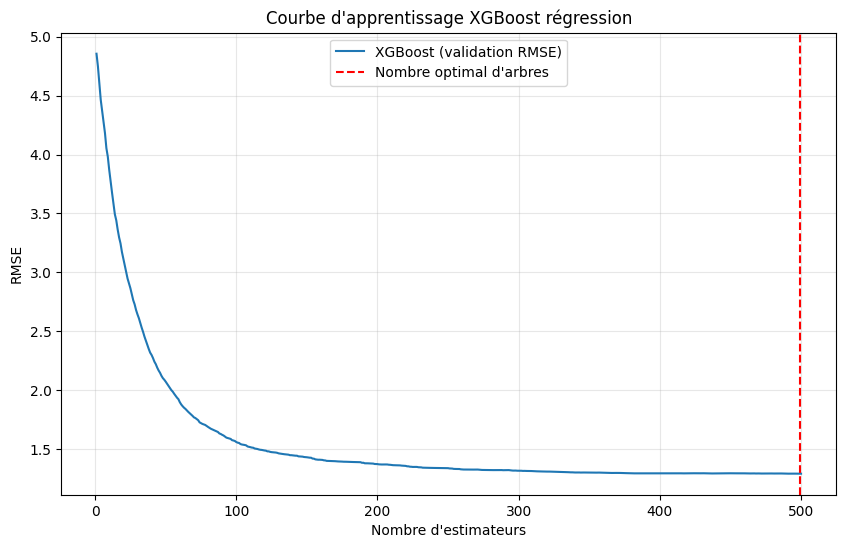

In [8]:
results = xgb_reg.evals_result()
n_estimators_range = range(1, len(results["validation_0"]["rmse"]) + 1)
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, results["validation_0"]["rmse"], label="XGBoost (validation RMSE)")
plt.axvline(x=np.argmin(results["validation_0"]["rmse"]) + 1,
            color="red", linestyle="--", label="Nombre optimal d'arbres")
plt.xlabel("Nombre d'estimateurs")
plt.ylabel("RMSE")
plt.title("Courbe d'apprentissage XGBoost régression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Importance des caractéristiques pour XGBoost

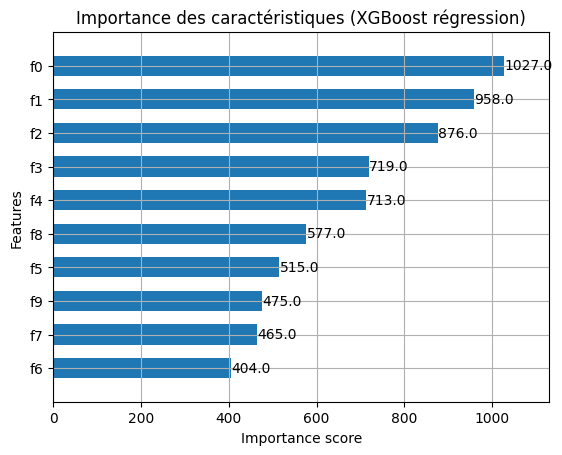

In [9]:
xgb.plot_importance(xgb_reg, max_num_features=10, height=0.6)
plt.title("Importance des caractéristiques (XGBoost régression)")
plt.show()

## 10. Explication des modèles avec SHAP

In [10]:
# Installer la bibliothèque SHAP si elle n'est pas déjà installée
!pip install shap

In [11]:
import shap

### SHAP pour le modèle XGBoost

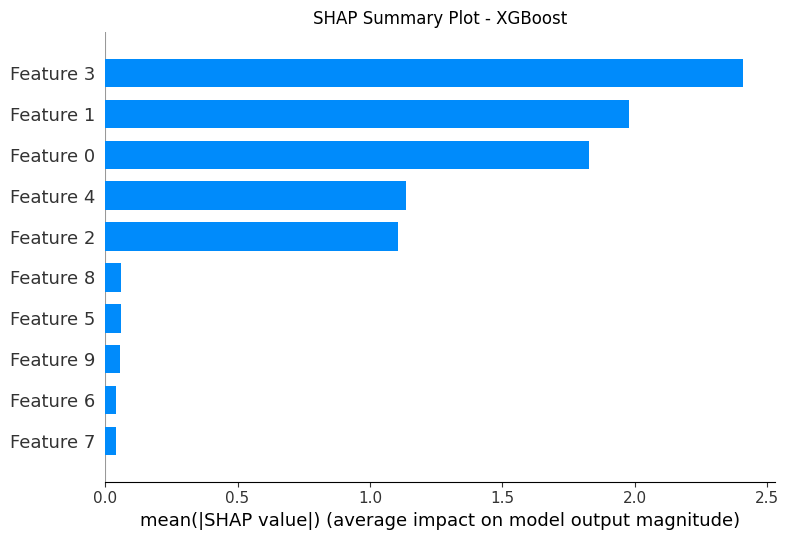

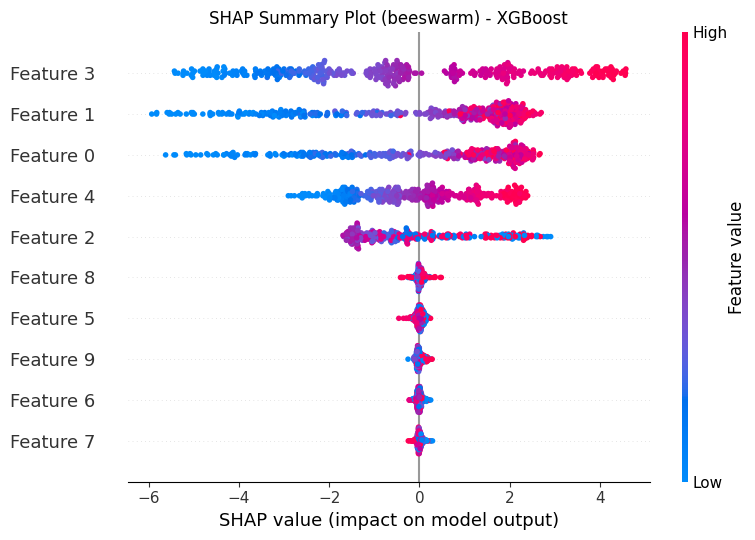

In [12]:
# Créer un explainer SHAP pour le modèle XGBoost
explainer_xgb = shap.TreeExplainer(xgb_reg)

# Calculer les valeurs SHAP pour l'ensemble de test
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Visualiser l'importance et l'impact des caractéristiques (summary plot)
plt.title("SHAP Summary Plot - XGBoost")
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar", show=False)
plt.show()

plt.title("SHAP Summary Plot (beeswarm) - XGBoost")
shap.summary_plot(shap_values_xgb, X_test, show=False)
plt.show()

### SHAP pour le modèle Gradient Boosting

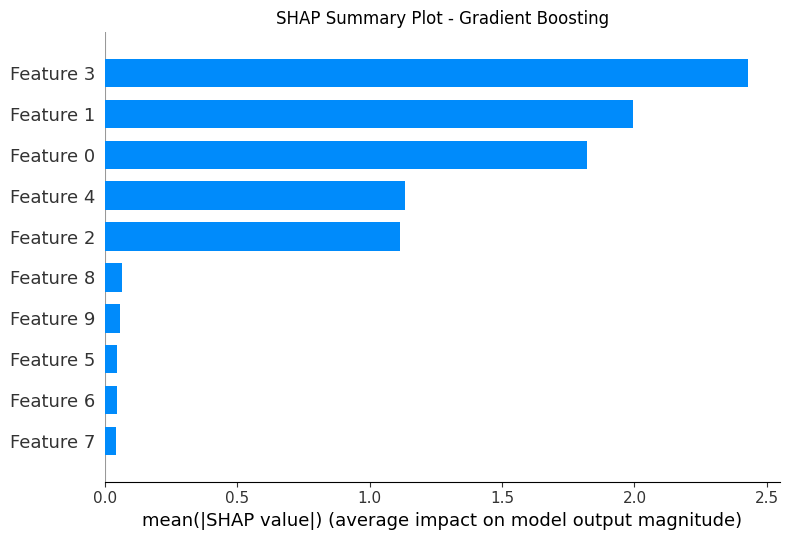

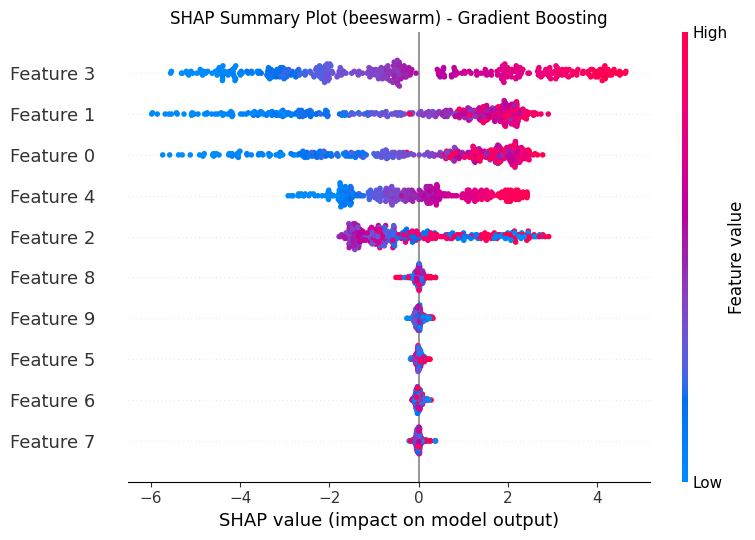

In [13]:
# Créer un explainer SHAP pour le modèle Gradient Boosting
explainer_gb = shap.TreeExplainer(gb_reg)

# Calculer les valeurs SHAP pour l'ensemble de test
shap_values_gb = explainer_gb.shap_values(X_test)

# Visualiser l'importance et l'impact des caractéristiques (summary plot)
plt.title("SHAP Summary Plot - Gradient Boosting")
shap.summary_plot(shap_values_gb, X_test, plot_type="bar", show=False)
plt.show()

plt.title("SHAP Summary Plot (beeswarm) - Gradient Boosting")
shap.summary_plot(shap_values_gb, X_test, show=False)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_friedman1
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb

# 1. Génération des données (Friedman #1)
X, y = make_friedman1(n_samples=2000, n_features=10, noise=1.0, random_state=42)

# 2. Division train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Modèle XGBoost régresseur avec early stopping
xgb_reg = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    reg_alpha=0.1,    # régularisation L1
    reg_lambda=1.0,   # régularisation L2
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# 4. Prédictions et métriques
y_pred_xgb = xgb_reg.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"XGBoost - MSE : {mse_xgb:.4f}, R² : {r2_xgb:.4f}")

# 5. Comparaison avec GradientBoostingRegressor de scikit-learn
gb_reg = GradientBoostingRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=3,
    random_state=42
)

gb_reg.fit(X_train, y_train)
y_pred_gb = gb_reg.predict(X_test)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
print(f"GradientBoosting - MSE : {mse_gb:.4f}, R² : {r2_gb:.4f}")

# 6. Visualisation de l'apprentissage (nombre d'arbres optimal)
results = xgb_reg.evals_result()
n_estimators_range = range(1, len(results["validation_0"]["rmse"]) + 1)
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, results["validation_0"]["rmse"], label="XGBoost (validation RMSE)")
plt.axvline(x=np.argmin(results["validation_0"]["rmse"]) + 1,
            color="red", linestyle="--", label="Nombre optimal d'arbres")
plt.xlabel("Nombre d'estimateurs")
plt.ylabel("RMSE")
plt.title("Courbe d'apprentissage XGBoost régression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Importance des caractéristiques
xgb.plot_importance(xgb_reg, max_num_features=10, height=0.6)
plt.title("Importance des caractéristiques (XGBoost régression)")
plt.show()